# Построение и обучение моделей

Были взяты следующие модели:

1. **MyCnn** — самописная сверточная сеть
2. **ConvNeXt-Tiny head only** — transfer learning
3. **ConvNeXt-Tiny fine-tuned** — transfer learning с размарозкой последнего блока
4. **ViT-B/16** — Vision Transformer, архитектура на self-attention.



In [ ]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import mlflow
mlflow.end_run()

2026/06/14 13:55:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/14 13:55:14 INFO mlflow.store.db.utils: Updating database tables


Создан новый эксперимент: 1
MLflow подключен: sqlite:////content/drive/MyDrive/GP5_DL_image_classification/mlflow/mlflow.db
Папка артефактов: /content/drive/MyDrive/GP5_DL_image_classification/mlflow/artifacts


In [ ]:
mlflow.set_tracking_uri(f"sqlite:///{mlflow_db_path.as_posix()}") #тут мы подключаем mlflow к sqlite базе

In [ ]:
experiment_name = 'architecture_styles_classification_final'
experiment = mlflow.get_experiment_by_name(experiment_name)

Мы смотрим есть ли уже такой эксперемент, и если есть подключаемся к нему, если нету создаем новый

In [ ]:
if experiment is None:
    experiment_id = mlflow.create_experiment(name = experiment_name, artifact_location=mlflow_artifacts_dir.resolve().as_uri())
else:
    experiment_id = experiment.experiment_id


In [ ]:
mlflow.set_experiment(experiment_name)

In [ ]:
print('MLflow подключен к ', mlflow.get_tracking_uri())
print('Куда сохраняються модели:', mlflow_artifacts_dir)

##**MyCnn**

**Описание слоев**:

    -> Вход: 3 x 224 x 224
    conv -> 16 x 112 x 112
    conv -> 32 x 56 x 56
    conv -> 64 x 28 x 28
    conv -> 128 x 14 x 14
    conv -> 256 x 7 x 7
    flatten
    fc -> 2048
    fc -> 1024
    fc -> 512
    Выход -> 19

In [ ]:
import torch.nn as nn

class MyCnn(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2))

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2))

        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2))

        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2))

        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2))

        self.fc1 = nn.Sequential(
            nn.Linear(256 * 7 * 7, 2048),
            nn.BatchNorm1d(2048),
            nn.GELU(),
            nn.Dropout(0.4))

        self.fc2 = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.4))

        self.fc3 = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4))

        self.out = nn.Linear(512, n_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)

        logits = self.out(x)
        return logits


In [ ]:
def save_checkpoint(model, optimizer, filename = 'checkpoint.pth', epoch = None, val_macro_f1 = None):
    filename = Path(filename)
    filename.parent.mkdir(parents = True, exist_ok = True)
    checkpoint = {'state_dict': model.state_dict(), 'optimizer': optimizer.state_dict(), 'epoch': epoch, 'val_macro_f1': val_macro_f1}
    torch.save(checkpoint, filename)

In [ ]:
def load_checkpoint(filepath, model_class, n_classes):
    filepath = Path(filepath)
    checkpoint = torch.load(filepath, map_location=torch.device('cpu'), weights_only=True)
    model = model_class(n_classes)
    model.load_state_dict(checkpoint['state_dict'])
    return model

In [ ]:
def fit_epoch(model, train_loader, criterion, optimizer, device = DEVICE):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    processed_data = 0

    for inputs, labels in tqdm(train_loader, desc='train', leave=False):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(outputs, dim=1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        processed_data += inputs.size(0)

    train_loss = running_loss / processed_data
    train_acc = running_corrects / processed_data
    return train_loss, train_acc

In [ ]:
def eval_epoch(model, val_loader, criterion, device=DEVICE):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0
    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(val_loader, desc='valid', leave=False):
        inputs = inputs.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        processed_size += inputs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / processed_size
    val_acc = running_corrects / processed_size
    val_macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return val_loss, val_acc, val_macro_f1

In [ ]:
def train(train_dataset, val_dataset, model, epochs, batch_size, optimizer, sampler,
          best_state_save_path = 'best_model.pth', run_name = 'experiment', history = None):

    train_loader = DataLoader(train_dataset, batch_size = batch_size, sampler = sampler, shuffle = False, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False, num_workers = 2, pin_memory = True)

    if history is None:
        history = []

    criterion = nn.CrossEntropyLoss()
    best_val_macro_f1 = -67
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    with mlflow.start_run(run_name=run_name) as run:
        run_id = run.info.run_id

        mlflow.log_params({
            'architecture': model.__class__.__name__,
            'optimizer': optimizer.__class__.__name__,
            'learning_rate': optimizer.param_groups[0]['lr'],
            'weight_decay': optimizer.param_groups[0].get('weight_decay', 0.0),
            'epochs': epochs,
            'batch_size': batch_size,
            'weighted_sampler': sampler,
            'total_params': total_params,
            'trainable_params': trainable_params,
            'n_classes': len(train_dataset.label_encoder.classes_),
            'seed': seed,
            'rescale_size': rescale_size,
            'dataset_source': 'stepanyarullin/interior-design-styles',
            'selection_metric': 'validation_macro_f1',
            'business_task': 'interior_style_tagging_for_real_estate_platform'})

        with tqdm(desc='epoch', total=epochs, leave=True) as pbar_outer:
            for epoch in range(epochs):
                train_loss, train_acc = fit_epoch(model, train_loader, criterion, optimizer)
                val_loss, val_acc, val_macro_f1 = eval_epoch(model, val_loader, criterion)
                history.append((train_loss, train_acc, val_loss, val_acc, val_macro_f1))
                mlflow.log_metrics({'train_loss': train_loss, 'train_accuracy': train_acc, 'val_loss': val_loss, 'val_accuracy': val_acc, 'val_macro_f1': val_macro_f1}, step = epoch + 1)
                pbar_outer.update(1)

                print(f'\nEpoch {(epoch + 1):03d} train_loss: {train_loss:0.4f} val_loss: {val_loss:0.4f} train_acc: {train_acc:0.4f} acc_val: {val_acc:0.4f} macro_f1_val: {val_macro_f1:0.4f}\n')

                if val_macro_f1 > best_val_macro_f1:
                    best_val_macro_f1 = val_macro_f1
                    save_checkpoint(model = model, optimizer = optimizer, filename = best_state_save_path, epoch = epoch + 1, val_macro_f1 = val_macro_f1)
                    print(f'Новая лучшая модель сохранена: val_macro_f1 = {val_macro_f1:.4f} epoch = {epoch + 1}')

        mlflow.log_metric('best_val_macro_f1', best_val_macro_f1)
        history_df = pd.DataFrame(history, columns = ['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'val_macro_f1'])
        history_path = reports_dir / f'{run_name}_train_history.csv'
        history_df.to_csv(history_path, index=False)
        mlflow.log_artifact(str(history_path), artifact_path='history')

        mlflow.log_artifact(str(best_state_save_path), artifact_path = 'checkpoints')
        mlflow.log_artifact(str(label_encoder_path), artifact_path = 'preprocessing')
        mlflow.log_artifact(str(split_manifest_path), artifact_path = 'data_split')

    return history, run_id


Эти три функции выше у нас обучают(функция обучения связана с двумя другими) и потом проверяю на валидационной выборке

In [ ]:
def predict(model, test_loader):
  with torch.no_grad():
    model.eval()
    logits = []
    for inputs in test_loader:
      inputs = inputs.to(DEVICE)
      outputs = model(inputs).cpu()
      logits.append(outputs)
  probs = nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
  return probs

In [ ]:
n_classes = len(label_encoder.classes_)
print(f'У нас  19 классов: {n_classes}')

cnn_model = MyCnn(n_classes).to(DEVICE)
print(cnn_model)

In [ ]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params

    print(f"Всего параметров: {total_params}")
    print(f"Обучаемых параметров: {trainable_params}")
    print(f"Не обучаемых параметров: {non_trainable_params}")
    return total_params, trainable_params, non_trainable_params

In [ ]:
count_parameters(cnn_model)

### Обучение

In [ ]:
train_sample_counts = Counter(train_dataset.labels)
sample_weights = [1.0 / train_sample_counts[label] for label in train_dataset.labels]
weighted_sampler = WeightedRandomSampler(weights=torch.tensor(sample_weights, dtype=torch.double), num_samples=len(sample_weights), replacement=True)

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
my_cnn_epochs = 30
batch_size = 128

optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)

history, cnn_run_id = train(
    train_dataset = train_dataset,
    val_dataset = val_dataset,
    model = cnn_model,
    epochs = my_cnn_epochs,
    batch_size = batch_size,
    optimizer = optimizer,
    sampler = weighted_sampler,
    best_state_save_path = checkpoints_dir / 'my_cnn_best.pth',
    run_name = 'MyCnn_AdamW1')

epoch:   0%|          | 0/20 [00:00<?, ?it/s]

train:   0%|          | 0/93 [00:00<?, ?it/s]

valid:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 001 train_loss: 2.8981 val_loss: 2.7967 train_acc: 0.0967 val_acc: 0.1237 val_macro_f1: 0.0996

New best model saved: val_macro_f1=0.0996, epoch=1


train:   0%|          | 0/93 [00:00<?, ?it/s]

...

valid:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 019 train_loss: 2.0780 val_loss: 2.6234 train_acc: 0.3580 val_acc: 0.2103 val_macro_f1: 0.2021



train:   0%|          | 0/93 [00:00<?, ?it/s]

valid:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 020 train_loss: 2.0060 val_loss: 2.6381 train_acc: 0.3834 val_acc: 0.2251 val_macro_f1: 0.2189

New best model saved: val_macro_f1=0.2189, epoch=20


In [ ]:
#heckpoint = torch.load('checkpoint.pth')

#cnn_model = MyCnn(n_classes=n_classes)
#cnn_model.load_state_dict(checkpoint['state_dict'])

#optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
#optimizer.load_state_dict(checkpoint['optimizer'])

#start_epoch = checkpoint['epoch'] + 1
#best_val_macro_f1 = checkpoint['val_macro_f1']

### Кривые обучения

In [ ]:
loss, acc, val_loss, val_acc, val_macro_f1 = zip(*history)

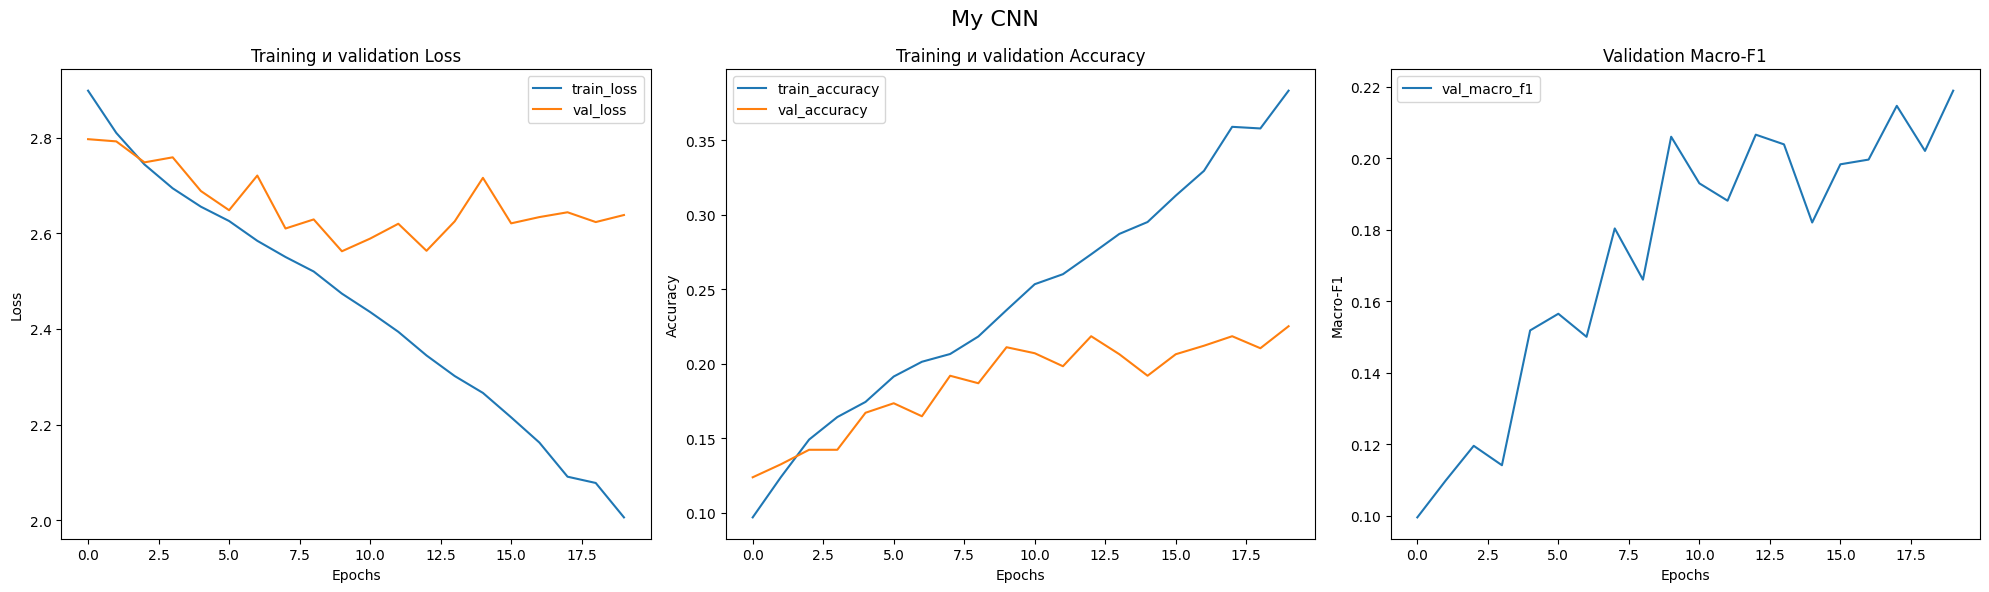

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('My CNN')

axes[0].plot(loss, label='train_loss')
axes[0].plot(val_loss, label='val_loss')
axes[0].legend(loc='best')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training и validation Loss')

axes[1].plot(acc, label='train_accuracy')
axes[1].plot(val_acc, label='val_accuracy')
axes[1].legend(loc='best')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training и validation Accuracy')

axes[2].plot(val_macro_f1, label='val_macro_f1')
axes[2].legend(loc='best')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Macro F1')
axes[2].set_title('Validation Macro F1')

plt.show()

### Предсказание

Для итогового предсказания используется модель с максимальным значением
macro F1 на валидационной выборке.

In [ ]:
cnn_model_best = load_checkpoint(checkpoints_dir / 'my_cnn_best.pth', MyCnn, n_classes)
cnn_model_best.to(DEVICE)
cnn_model_best.eval()

MyCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (

In [ ]:
def predict_one_sample(model, inputs, device = DEVICE):
  with torch.no_grad():
    inputs = inputs.to(device)
    model.eval()
    logit = model(inputs).cpu()
    probs = torch.nn.functional.softmax(logit, dim = -1).numpy()
  return probs

In [ ]:
label_encoder = pickle.load(open(label_encoder_path, 'rb'))

### Метрика

Метрика, которую необходимо оптимизировать - *f1-score*. Вычислим целевую метрику на тестовой выборке.

In [ ]:
label_encoder = pickle.load(open(label_encoder_path, 'rb'))

test_dataset = InteriorDataset(test_files, mode = 'test')
test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 128)

In [ ]:
probs = predict(cnn_model_best, test_loader)
y_pred = np.argmax(probs, axis = 1)

Test macro-F1: 0.22612292176626178
Test micro-F1: 0.23035666398498256


In [ ]:
preds_class = label_encoder.inverse_transform(y_pred)

In [ ]:
test_filenames = [path.name for path in test_dataset.files]

In [ ]:
predictions_df = pd.DataFrame({'filename': test_filenames, 'predicted': preds_class})
merged_df = test_labels_df.merge(predictions_df, on = 'filename', how = 'inner', validate = 'one_to_one')

In [ ]:
assert len(merged_df) == len(test_labels_df), ('Пикчи не найдены')

In [ ]:
my_cnn_predictions_path = predictions_dir / 'my_cnn_predictions.csv'
merged_df.to_csv(my_cnn_predictions_path, index = False, encoding = 'utf-8')

In [ ]:
test_macro_f1 = f1_score(merged_df['style'], merged_df['predicted'], average='macro', zero_division=0)
test_micro_f1 = f1_score(merged_df['style'], merged_df['predicted'], average='micro', zero_division=0)
print('Test macro F1:', test_macro_f1)
print('Test micro F1:', test_micro_f1)

In [ ]:
with mlflow.start_run(run_id = cnn_run_id):
    mlflow.log_metrics({'test_macro_f1': test_macro_f1, 'test_micro_f1': test_micro_f1})
    mlflow.log_artifact(str(my_cnn_predictions_path), artifact_path = 'predictions')

In [ ]:
runs = mlflow.search_runs(experiment_names = [experiment_name])
columns = ['tags.mlflow.runName', 'params.architecture', 'params.learning_rate', 'params.batch_size', 'metrics.best_val_macro_f1', 'metrics.test_macro_f1']

In [ ]:
runs = mlflow.search_runs(experiment_names = [experiment_name])

columns = ['tags.mlflow.runName',
           'params.architecture',
           'params.learning_rate',
           'params.batch_size',
           'metrics.best_val_macro_f1',
           'metrics.test_macro_f1']

runs_table = runs.reindex(columns = columns)

runs_table = runs_table.dropna(subset=['metrics.best_val_macro_f1', 'metrics.test_macro_f1'])

display(runs_table)


,tags.mlflow.runName,params.architecture,params.learning_rate,params.batch_size,metrics.best_val_macro_f1,metrics.test_macro_f1
0,MyCnn_AdamW1,MyCnn,0.001,128,0.218931,0.226123
1,MyCnn_AdamW1,MyCnn,0.001,128,NaN,NaN


### Визуализация уверенности модели в предсказаниях

In [ ]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties


def imshow(image, title, plt_ax):
    image = image.detach().cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)
    if plt_ax is None:
        plt_ax = plt.gca()
    plt_ax.imshow(image)
    plt_ax.axis('off')
    plt_ax.set_title(title)

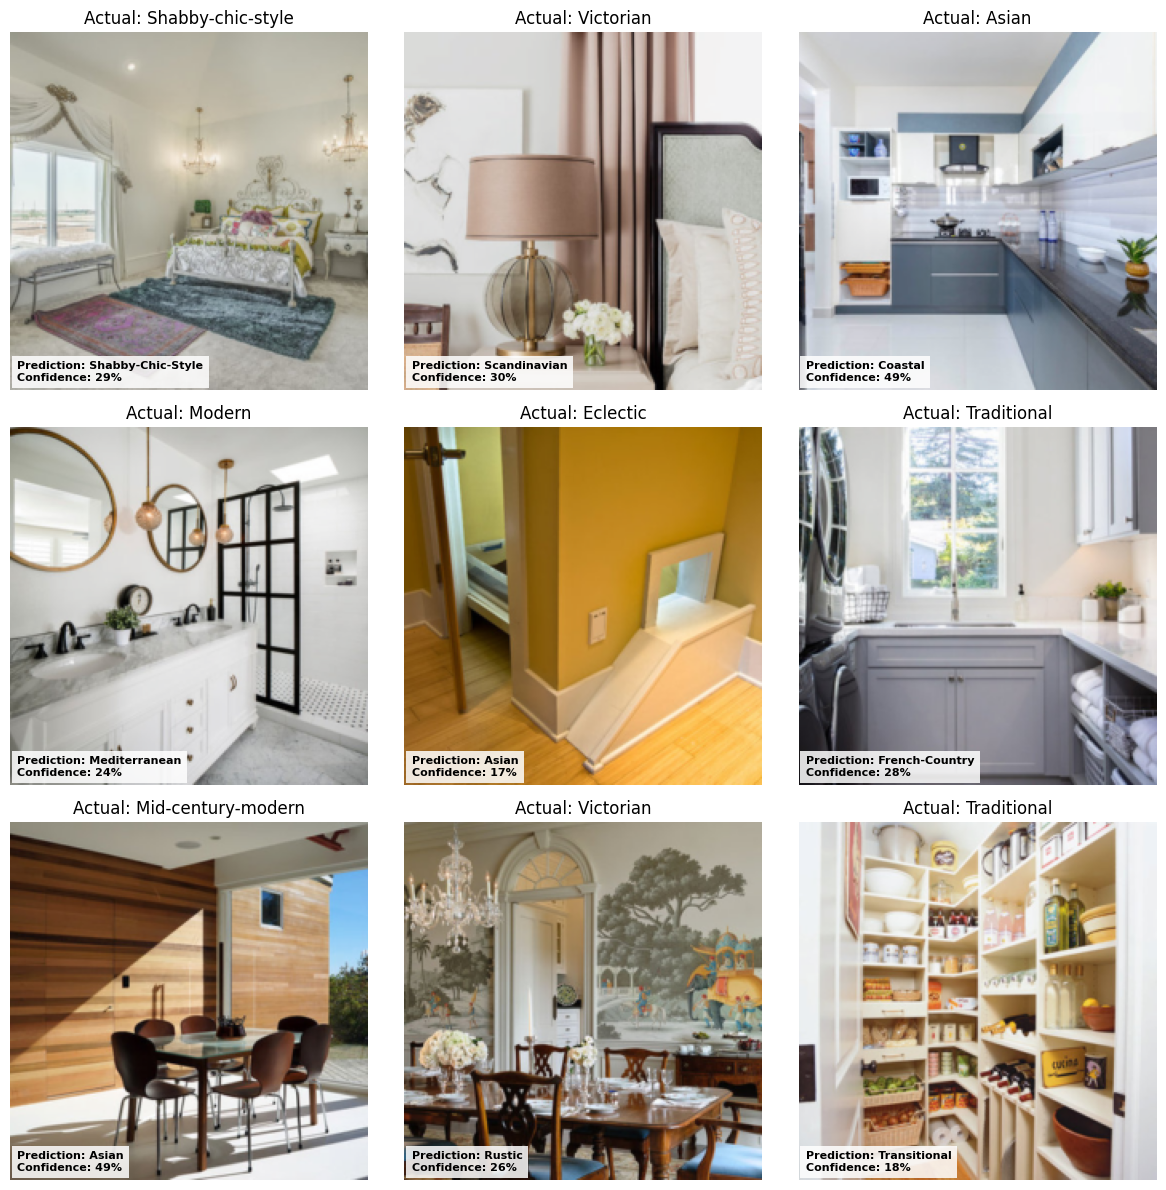

In [ ]:
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (12, 12), sharey = True, sharex = True)
for x in ax.flatten():
    random_character = np.random.randint(0, len(val_dataset))
    im_val, label = val_dataset[random_character]
    img_label = ' '.join(map(lambda x: x.capitalize(), val_dataset.label_encoder.inverse_transform([label])[0].split('_')))
    imshow(im_val, title = f'Настоящий: {img_label}', plt_ax = x)

    inputs = im_val.unsqueeze(0)
    prob_pred = predict_one_sample(cnn_model_best, inputs)[0]
    y_pred = np.argmax(prob_pred)

    predicted_label = label_encoder.classes_[y_pred]
    predicted_proba = prob_pred[y_pred] * 100
    predicted_label = predicted_label.replace('_', ' ').title()
    predicted_text = 'Предсказанный: {}\Уверенность модели: {:.0f}%'.format(predicted_label, predicted_proba)

    x.text(0.025, 0.025, predicted_text, transform = x.transAxes, horizontalalignment = 'left', verticalalignment = 'bottom', fontsize = 8, color = 'black', fontweight = 'bold', bbox = {'facecolor': 'white', 'alpha': 0.6, 'edgecolor': 'none'})

plt.show()

## Transfer Learning: ConvNeXt-Tiny


In [ ]:
import torchvision.models as models

class ConvNeXtTinyTransferModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.model = models.convnext_tiny(weights = models.ConvNeXt_Tiny_Weights.DEFAULT)

        in_features = self.model.classifier[2].in_features
        self.model.classifier[2] = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, n_classes))

    def forward(self, x):
        return self.model(x)


In [ ]:
transfer_model = ConvNeXtTinyTransferModel(n_classes).to(DEVICE)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 174MB/s]


Total parameters: 28223603
Trainable parameters: 405011
Non-trainable parameters: 27818592


(28223603, 405011, 27818592)

In [ ]:
for param in transfer_model.model.parameters():
    param.requires_grad = False

for param in transfer_model.model.classifier.parameters():
    param.requires_grad = True

In [ ]:
for param in transfer_model.model.classifier.parameters():
    param.requires_grad = True
transfer_optimizer = torch.optim.AdamW(filter(lambda param: param.requires_grad, transfer_model.parameters()),lr = 3e-4, weight_decay = 1e-4)

In [ ]:
count_parameters(transfer_model)

In [ ]:
transfer_epochs = 20
transfer_batch_size = 32

transfer_history, transfer_run_id = train(
    train_dataset = train_dataset,
    val_dataset = val_dataset,
    model = transfer_model,
    epochs = transfer_epochs,
    batch_size = transfer_batch_size,
    optimizer = transfer_optimizer,
    sampler = weighted_sampler,
    best_state_save_path = checkpoints_dir / 'convnext_tiny_best.pth',
    run_name = 'ConvNeXtTiny_head_only')


epoch:   0%|          | 0/5 [00:00<?, ?it/s]

train:   0%|          | 0/372 [00:00<?, ?it/s]

valid:   0%|          | 0/93 [00:00<?, ?it/s]


Epoch 001 train_loss: 2.5618 val_loss: 2.3564 train_acc: 0.2192 val_acc: 0.2735 val_macro_f1: 0.2714

New best model saved: val_macro_f1=0.2714, epoch=1


train:   0%|          | 0/372 [00:00<?, ?it/s]

...

valid:   0%|          | 0/93 [00:00<?, ?it/s]


Epoch 004 train_loss: 2.0813 val_loss: 2.1569 train_acc: 0.3572 val_acc: 0.3313 val_macro_f1: 0.3262

New best model saved: val_macro_f1=0.3262, epoch=4


train:   0%|          | 0/372 [00:00<?, ?it/s]

valid:   0%|          | 0/93 [00:00<?, ?it/s]


Epoch 005 train_loss: 2.0324 val_loss: 2.1638 train_acc: 0.3746 val_acc: 0.3367 val_macro_f1: 0.3286

New best model saved: val_macro_f1=0.3286, epoch=5


In [ ]:
transfer_model_best = load_checkpoint(checkpoints_dir / 'convnext_tiny_best.pth', ConvNeXtTinyTransferModel, n_classes)
transfer_model_best.to(DEVICE)

ConvNeXtTinyTransferModel(
  (model): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): Lay

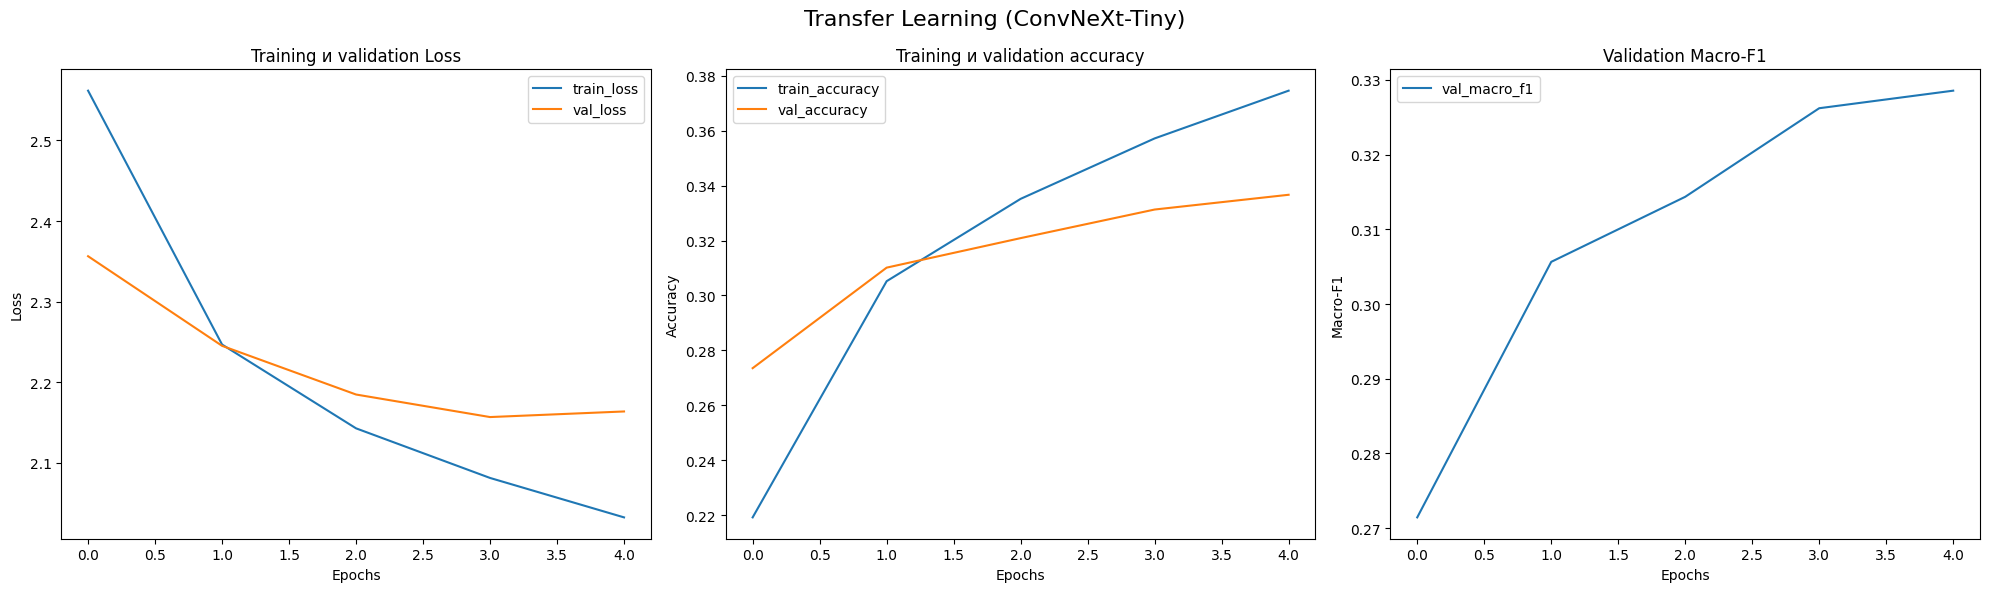

In [ ]:
transfer_loss, transfer_acc, transfer_val_loss, transfer_val_acc, transfer_val_macro_f1 = zip(*transfer_history)

fig, axes = plt.subplots(1, 3, figsize = (20, 6))
fig.suptitle('Transfer Learning (ConvNeXt-Tiny)')

axes[0].plot(transfer_loss, label = 'train_loss')
axes[0].plot(transfer_val_loss, label = 'val_loss')
axes[0].legend(loc = 'best')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training и validation Loss')

axes[1].plot(transfer_acc, label = 'train_accuracy')
axes[1].plot(transfer_val_acc, label = 'val_accuracy')
axes[1].legend(loc='best')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training и validation accuracy')

axes[2].plot(transfer_val_macro_f1, label = 'val_macro_f1')
axes[2].legend(loc='best')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Macro F1')
axes[2].set_title('Validation Macro F1')

plt.show()

In [ ]:
label_encoder = pickle.load(open(label_encoder_path, 'rb'))
transfer_test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 32)

In [ ]:
transfer_probs = predict(transfer_model_best, transfer_test_loader)
transfer_y_pred = np.argmax(transfer_probs, axis = 1)

In [ ]:
transfer_preds_class = label_encoder.inverse_transform(transfer_y_pred)

In [ ]:
test_filenames = [path.name for path in test_dataset.files]

In [ ]:
transfer_predictions_df = pd.DataFrame({'filename': test_filenames, 'predicted': transfer_preds_class})
transfer_merged_df = test_labels_df.merge(transfer_predictions_df, on = 'filename', how = 'inner', validate = 'one_to_one')

In [ ]:
assert len(transfer_merged_df) == len(test_labels_df), ('Пикчи потерялись')

In [ ]:
convnext_predictions_path = predictions_dir / 'convnext_tiny_predictions.csv'
transfer_merged_df.to_csv(convnext_predictions_path, index = False, encoding = 'utf-8')

In [ ]:
transfer_test_macro_f1 = f1_score(transfer_merged_df['style'], transfer_merged_df['predicted'], average = 'macro', zero_division = 0)
transfer_test_micro_f1 = f1_score(transfer_merged_df['style'], transfer_merged_df['predicted'], average = 'micro', zero_division = 0)

print('ConvNeXt-Tiny test macro F1:', transfer_test_macro_f1)
print('ConvNeXt-Tiny test micro F1:', transfer_test_micro_f1)

In [ ]:
with mlflow.start_run(run_id = transfer_run_id):
    mlflow.log_metrics({'test_macro_f1': transfer_test_macro_f1,
                        'test_micro_f1': transfer_test_micro_f1})
    mlflow.log_artifact(str(convnext_predictions_path), artifact_path = 'predictions')

## Размареженный transfer learning: ConvNeXt-Tiny


In [ ]:
convnext_finetune_model = load_checkpoint(checkpoints_dir / 'convnext_tiny_best.pth', ConvNeXtTinyTransferModel, n_classes).to(DEVICE)

Total parameters: 28223603
Trainable parameters: 14694419
Non-trainable parameters: 13529184


(28223603, 14694419, 13529184)

In [ ]:
for param in convnext_finetune_model.model.parameters():
    param.requires_grad = False

for param in convnext_finetune_model.model.features[-1].parameters():
    param.requires_grad = True

for param in convnext_finetune_model.model.classifier.parameters():
    param.requires_grad = True

In [ ]:
convnext_finetune_optimizer = torch.optim.AdamW(filter(lambda param: param.requires_grad, convnext_finetune_model.parameters()), lr = 1e-5, weight_decay = 1e-4)

In [ ]:
count_parameters(convnext_finetune_model)

In [ ]:
convnext_finetune_epochs = 20
convnext_finetune_batch_size = 32

convnext_finetune_history, convnext_finetune_run_id = train(
    train_dataset = train_dataset,
    val_dataset = val_dataset,
    model = convnext_finetune_model,
    epochs = convnext_finetune_epochs,
    batch_size = convnext_finetune_batch_size,
    optimizer = convnext_finetune_optimizer,
    sampler = weighted_sampler,
    best_state_save_path = checkpoints_dir / 'convnext_tiny_finetuned_best.pth',
    run_name = 'ConvNeXtTiny_finetuned_last_block')


epoch:   0%|          | 0/5 [00:00<?, ?it/s]

train:   0%|          | 0/372 [00:00<?, ?it/s]

valid:   0%|          | 0/93 [00:00<?, ?it/s]


Epoch 001 train_loss: 1.9879 val_loss: 2.1285 train_acc: 0.3866 val_acc: 0.3448 val_macro_f1: 0.3388

New best model saved: val_macro_f1=0.3388, epoch=1


train:   0%|          | 0/372 [00:00<?, ?it/s]

...

valid:   0%|          | 0/93 [00:00<?, ?it/s]


Epoch 004 train_loss: 1.8795 val_loss: 2.0952 train_acc: 0.4142 val_acc: 0.3525 val_macro_f1: 0.3485

New best model saved: val_macro_f1=0.3485, epoch=4


train:   0%|          | 0/372 [00:00<?, ?it/s]

valid:   0%|          | 0/93 [00:00<?, ?it/s]


Epoch 005 train_loss: 1.8482 val_loss: 2.0882 train_acc: 0.4303 val_acc: 0.3582 val_macro_f1: 0.3547

New best model saved: val_macro_f1=0.3547, epoch=5


In [ ]:
convnext_finetune_model_best = load_checkpoint(checkpoints_dir / 'convnext_tiny_finetuned_best.pth', ConvNeXtTinyTransferModel, n_classes).to(DEVICE)


In [ ]:
label_encoder = pickle.load(open(LABEL_ENCODER_PATH, 'rb'))

convnext_finetune_test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 32)

In [ ]:
convnext_finetune_probs = predict(convnext_finetune_model_best, convnext_finetune_test_loader)
convnext_finetune_y_pred = np.argmax(convnext_finetune_probs, axis = 1)

In [ ]:
convnext_finetune_preds_class = label_encoder.inverse_transform(convnext_finetune_y_pred)

In [ ]:
convnext_finetune_predictions_df = pd.DataFrame({'filename': [path.name for path in test_dataset.files], 'predicted': convnext_finetune_preds_class})
convnext_finetune_merged_df = test_labels_df.merge(convnext_finetune_predictions_df, on='filename', how='inner', validate='one_to_one')

In [ ]:
assert len(convnext_finetune_merged_df) == len(test_labels_df), ('Пикчи потерялись')

In [ ]:
convnext_finetuned_predictions_path = predictions_dir / 'convnext_tiny_finetuned_predictions.csv'
convnext_finetune_merged_df.to_csv(convnext_finetuned_predictions_path, index=False, encoding='utf-8')

In [ ]:
convnext_finetune_test_macro_f1 = f1_score(convnext_finetune_merged_df['style'], convnext_finetune_merged_df['predicted'], average='macro', zero_division=0)
convnext_finetune_test_micro_f1 = f1_score(convnext_finetune_merged_df['style'], convnext_finetune_merged_df['predicted'], average='micro', zero_division=0)

print('ConvNeXt-Tiny fine_tuning test macro F1:', convnext_finetune_test_macro_f1)
print('ConvNeXt-Tiny fine_tuning test micro F1:', convnext_finetune_test_micro_f1)

In [ ]:
with mlflow.start_run(run_id=convnext_finetune_run_id):
    mlflow.log_params({'fine_tuning': True, 'unfrozen_part': 'last_feature_block_and_classifier'})
    mlflow.log_metrics({'test_macro_f1': convnext_finetune_test_macro_f1, 'test_micro_f1': convnext_finetune_test_micro_f1})
    mlflow.log_artifact(str(convnext_finetuned_predictions_path), artifact_path='predictions')

## Vision Transformer ViT-B/16


In [ ]:
class ViTB16TransferModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.model = models.vit_b_16(weights = models.ViT_B_16_Weights.DEFAULT)

        in_features = self.model.heads.head.in_features
        self.model.heads.head = nn.Sequential(nn.Linear(in_features, 256),
                                              nn.GELU(),
                                              nn.Dropout(0.3),
                                              nn.Linear(256, n_classes))

    def forward(self, x):
        return self.model(x)


In [ ]:
vit_model = ViTB16TransferModel(n_classes).to(DEVICE)

In [ ]:
for param in vit_model.model.parameters():
    param.requires_grad = False

for param in vit_model.model.heads.parameters():
    param.requires_grad = True

In [ ]:
vit_optimizer = torch.optim.AdamW(filter(lambda param: param.requires_grad, vit_model.parameters()), lr = 3e-4, weight_decay = 1e-4)
count_parameters(vit_model)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 162MB/s]


Total parameters: 86000403
Trainable parameters: 201747
Non-trainable parameters: 85798656


(86000403, 201747, 85798656)

### Обучение ViT-B/16

Используем тот же `WeightedRandomSampler`, что и для предыдущих моделей. Это сохраняет сопоставимость экспериментов при дисбалансе классов. Для ViT установлен меньший `batch_size=16`, поскольку модель тяжелее ConvNeXt-Tiny. При нехватке видеопамяти в Colab значение можно уменьшить до `8`.


In [ ]:
vit_epochs = 20
vit_batch_size = 16

vit_history, vit_run_id = train(
    train_dataset = train_dataset,
    val_dataset = val_dataset,
    model = vit_model,
    epochs = vit_epochs,
    batch_size = vit_batch_size,
    optimizer = vit_optimizer,
    sampler = weighted_sampler,
    best_state_save_path = checkpoints_dir / 'vit_b16_best.pth',
    run_name = 'ViT_B16_head_only')


In [ ]:
vit_model_best = load_checkpoint(checkpoints_dir / 'vit_b16_best.pth', ViTB16TransferModel, n_classes)

In [ ]:
vit_model_best.to(DEVICE)

### Кривые обучения ViT-B/16


In [ ]:
vit_loss, vit_acc, vit_val_loss, vit_val_acc, vit_val_macro_f1 = zip(*vit_history)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (20, 6))
fig.suptitle('Transfer Learning (ViT-B/16)', fontsize = 16)

axes[0].plot(vit_loss, label = 'train_loss')
axes[0].plot(vit_val_loss, label = 'val_loss')
axes[0].legend(loc='best')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training и validation Loss')

axes[1].plot(vit_acc, label = 'train_accuracy')
axes[1].plot(vit_val_acc, label = 'val_accuracy')
axes[1].legend(loc='best')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training и validation Accuracy')

axes[2].plot(vit_val_macro_f1, label = 'val_macro_f1')
axes[2].legend(loc='best')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Macro F1')
axes[2].set_title('Validation Macro F1')

plt.tight_layout()
plt.show()


### Предсказания ViT-B/16 на тестовой выборке


In [ ]:
label_encoder = pickle.load(open(label_encoder_path, 'rb'))
vit_test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 16)

In [ ]:
vit_probs = predict(vit_model_best, vit_test_loader)
vit_y_pred = np.argmax(vit_probs, axis = 1)

In [ ]:
vit_preds_class = label_encoder.inverse_transform(vit_y_pred)

In [ ]:
vit_test_filenames = [path.name for path in test_dataset.files]

In [ ]:
vit_predictions_df = pd.DataFrame({'filename': vit_test_filenames, 'predicted': vit_preds_class})
vit_merged_df = test_labels_df.merge(vit_predictions_df, on = 'filename', how = 'inner', validate = 'one_to_one')

In [ ]:
assert len(vit_merged_df) == len(test_labels_df), ('Пикчи потерялись')

In [ ]:
vit_predictions_path = predictions_dir / 'vit_b16_predictions.csv'
vit_merged_df.to_csv(vit_predictions_path, index = False, encoding = 'utf-8')

In [ ]:
vit_test_macro_f1 = f1_score(vit_merged_df['style'], vit_merged_df['predicted'], average = 'macro', zero_division = 0)
vit_test_micro_f1 = f1_score(vit_merged_df['style'], vit_merged_df['predicted'], average = 'micro', zero_divisio = 0)

print('ViT-B/16 test macro F1:', vit_test_macro_f1)
print('ViT-B/16 test micro F1:',vit_test_micro_f1)

In [ ]:
with mlflow.start_run(run_id=vit_run_id):
    mlflow.log_metrics({'test_macro_f1': vit_test_macro_f1,
                        'test_micro_f1': vit_test_micro_f1})
    mlflow.log_artifact(str(vit_predictions_path), artifact_path = 'predictions')

## Сравнение всех четырёх архитектур

In [ ]:
runs = mlflow.search_runs(experiment_names = [experiment_name])

In [ ]:
columns = ['tags.mlflow.runName', 'params.architecture', 'params.optimizer', 'params.learning_rate', 'params.batch_size', 'params.total_params', 'params.trainable_params', 'metrics.best_val_macro_f1', 'metrics.test_macro_f1', 'metrics.test_micro_f1']

In [ ]:
runs_table = runs.reindex(columns = columns)
runs_table = runs_table.dropna(subset = ['metrics.best_val_macro_f1'])
runs_table = runs_table.sort_values(by = 'metrics.best_val_macro_f1', ascending = False)

display(runs_table)

In [ ]:
convnext_finetune_loss, convnext_finetune_acc, convnext_finetune_val_loss, convnext_finetune_val_acc, convnext_finetune_val_macro_f1 = zip(*convnext_finetune_history)

comparison_df = pd.DataFrame({'model': ['My CNN', 'ConvNeXt-Tiny', 'ConvNeXt-Tiny fine-tuned', 'ViT-B/16'],
    'best_val_macro_f1': [max(val_macro_f1), max(transfer_val_macro_f1), max(convnext_finetune_val_macro_f1), max(vit_val_macro_f1)],
    'test_macro_f1': [test_macro_f1, transfer_test_macro_f1, convnext_finetune_test_macro_f1, vit_test_macro_f1],
    'test_micro_f1': [test_micro_f1, transfer_test_micro_f1, convnext_finetune_test_micro_f1, vit_test_micro_f1]}).sort_values(by='best_val_macro_f1', ascending = False).reset_index(drop = True)

In [ ]:
metric_columns = ['best_val_macro_f1', 'test_macro_f1', 'test_micro_f1']

comparison_df[metric_columns] = comparison_df[metric_columns].apply(pd.to_numeric, errors = 'coerce')

comparison_df = comparison_df.dropna(subset=['best_val_macro_f1', 'test_macro_f1', 'test_micro_f1'])

comparison_df = comparison_df.sort_values(by='best_val_macro_f1', ascending=False).reset_index(drop=True)

display(comparison_df)
best_model_name = comparison_df.loc[0, 'model']

In [ ]:
print('Лучшая модель по val macro F1:', best_model_name)
print('Тестовая macro F1 лучшей модели.:', comparison_df.loc[0, 'test_macro_f1'])